# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

*Исходные данные:*

Данные находятся в файле /datasets/autos.csv <br />
Признаки<br />
- DateCrawled — дата скачивания анкеты из базы
- VehicleType — тип автомобильного кузова
- RegistrationYear — год регистрации автомобиля
- Gearbox — тип коробки передач
- Power — мощность (л. с.)
- Model — модель автомобиля
- Kilometer — пробег (км)
- RegistrationMonth — месяц регистрации автомобиля
- FuelType — тип топлива
- Brand — марка автомобиля
- Repaired — была машина в ремонте или нет
- DateCreated — дата создания анкеты
- NumberOfPictures — количество фотографий автомобиля
- PostalCode — почтовый индекс владельца анкеты (пользователя)
- LastSeen — дата последней активности пользователя

Целевой признак<br />
- Price — цена (евро)
    
*Ход работы:*

    1. Загрузка и изучение данных. Заполнение пропущенные значения и обработка аномалии в столбцах. Удаление неинформативных признаков.
    2. Подготовка выборки для обучения моделей.
    3. Обучение разных моделей, одна из которых — LightGBM, как минимум одна — не бустинг. Подбор разных гиперпараметров для каждой модели.
    4. Анализ времени обучения, время предсказания и качества моделей.
    5. Выбор лучшей модели и проверка её качества на тестовой выборке.

In [1]:
!pip install -U scikit-learn -q
!pip install lightgbm -q
!pip install phik -q
!pip install optuna -q
!pip install optuna-integration -q

In [2]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

# подготовка данных
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import (FunctionTransformer, 
                                   TargetEncoder, 
                                   OneHotEncoder, 
                                   OrdinalEncoder, 
                                   StandardScaler, 
                                   MinMaxScaler)
from sklearn.impute import SimpleImputer, KNNImputer

# пайплан
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# метрики оценки качества модели
from sklearn.metrics import root_mean_squared_error as RMSE

# модели
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor

# подбор гиперпараметров
#from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import optuna
from optuna.integration import OptunaSearchCV

# модель градиентного спуска LightGMB
import lightgbm as lgb
from lightgbm import LGBMRegressor

import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix

In [3]:
RANDOM_STATE = 133
TEST_SIZE = 0.25

## Подготовка данных

### Закрузка данных

In [4]:
df_autos = pd.read_csv('https://code.s3.yandex.net/datasets/autos.csv', parse_dates=['DateCrawled', 'DateCreated'])
df_autos.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31,0,60437,2016-04-06 10:17:21


In [5]:
df_autos.drop(['DateCrawled'], axis=1).duplicated().sum()

89

In [6]:
df_autos = df_autos.drop_duplicates(subset=['Price', 'VehicleType', 'RegistrationYear', 'Gearbox',
       'Power', 'Model', 'Kilometer', 'RegistrationMonth', 'FuelType', 'Brand',
       'Repaired', 'DateCreated', 'NumberOfPictures', 'PostalCode',
       'LastSeen'])
df_autos.duplicated().sum()

0

In [7]:
df_autos.drop(['DateCrawled'], axis=1).duplicated().sum()

0

In [8]:
df_autos['PostalZone'] = (df_autos['PostalCode'] / 1000).astype(int)
df_autos.sample(5)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen,PostalZone
312722,2016-03-30 16:57:18,2105,wagon,1999,auto,165,a6,150000,5,petrol,audi,no,2016-03-30,0,89434,2016-04-03 07:15:29,89
29110,2016-03-19 15:52:59,900,wagon,1999,manual,92,v40,150000,3,petrol,volvo,no,2016-03-19,0,24222,2016-04-01 03:46:54,24
331867,2016-03-21 14:25:22,18500,wagon,2010,manual,184,3er,150000,12,gasoline,bmw,no,2016-03-21,0,61440,2016-04-07 08:17:02,61
6406,2016-03-24 19:42:30,800,NaN,2016,manual,75,civic,150000,9,NaN,honda,NaN,2016-03-20,0,30966,2016-04-07 03:44:59,30
33074,2016-03-14 03:48:36,850,NaN,1990,manual,0,transporter,150000,0,NaN,volkswagen,NaN,2016-03-13,0,55758,2016-04-01 06:17:34,55


In [9]:
# удаление ненужных для моделей колонок "дата скачивания анкеты из базы", "дата создания анкеты",
#"месяц регистрации автомобиля", "количество фотографий автомобиля",
#"почтовый индекс владельца анкеты (пользователя)" - вместо него добавлена почтовая зона,
#"дата последней активности пользователя"
df_autos = df_autos.drop(['NumberOfPictures', 
                          'PostalCode', 
                          'LastSeen'], axis=1)
df_autos.sample(6)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,PostalZone
32665,2016-03-31 17:45:26,8750,small,2012,manual,69,panda,20000,2,petrol,fiat,no,2016-03-31,42
333533,2016-03-06 18:47:27,19350,suv,2008,auto,224,m_klasse,150000,6,gasoline,mercedes_benz,no,2016-03-06,75
59082,2016-03-31 21:50:38,4555,NaN,2000,NaN,0,transporter,150000,0,gasoline,volkswagen,NaN,2016-03-31,64
261906,2016-04-04 21:51:44,4950,coupe,2005,manual,150,fiesta,150000,11,petrol,ford,no,2016-04-04,55
206711,2016-03-05 18:49:20,3500,wagon,2004,manual,136,6_reihe,150000,6,gasoline,mazda,no,2016-03-05,32
163461,2016-03-23 01:57:25,2299,wagon,2002,manual,0,3er,5000,8,petrol,bmw,no,2016-03-23,51


In [10]:
df_autos.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 354280 entries, 0 to 354368
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   DateCrawled        354280 non-null  datetime64[ns]
 1   Price              354280 non-null  int64         
 2   VehicleType        316790 non-null  object        
 3   RegistrationYear   354280 non-null  int64         
 4   Gearbox            334448 non-null  object        
 5   Power              354280 non-null  int64         
 6   Model              334575 non-null  object        
 7   Kilometer          354280 non-null  int64         
 8   RegistrationMonth  354280 non-null  int64         
 9   FuelType           321388 non-null  object        
 10  Brand              354280 non-null  object        
 11  Repaired           283131 non-null  object        
 12  DateCreated        354280 non-null  datetime64[ns]
 13  PostalZone         354280 non-null  int64   

После удаления дубликатов (выгрузки одного и того же объявления несколько раз) осталось 354280 записей. Явные пропуски есть в VehicleType, Gearbox, Model, FuelType, Repaired. В целевом признаке Price пропусков нет.

Параметры DateCrawled, RegistrationMonth, DateCreated будут удалены позже, после анализа данных. Для обучения моделей они использоваться не будут.

### Проверка неявных дубликатов и просмотр встречающихся значений

In [11]:
df_autos['VehicleType'].unique()

array([nan, 'coupe', 'suv', 'small', 'sedan', 'convertible', 'bus',
       'wagon', 'other'], dtype=object)

In [12]:
df_autos['Gearbox'].unique()

array(['manual', 'auto', nan], dtype=object)

In [13]:
df_autos['Model'].unique()

array(['golf', nan, 'grand', 'fabia', '3er', '2_reihe', 'other', 'c_max',
       '3_reihe', 'passat', 'navara', 'ka', 'polo', 'twingo', 'a_klasse',
       'scirocco', '5er', 'meriva', 'arosa', 'c4', 'civic', 'transporter',
       'punto', 'e_klasse', 'clio', 'kadett', 'kangoo', 'corsa', 'one',
       'fortwo', '1er', 'b_klasse', 'signum', 'astra', 'a8', 'jetta',
       'fiesta', 'c_klasse', 'micra', 'vito', 'sprinter', '156', 'escort',
       'forester', 'xc_reihe', 'scenic', 'a4', 'a1', 'insignia', 'combo',
       'focus', 'tt', 'a6', 'jazz', 'omega', 'slk', '7er', '80', '147',
       '100', 'z_reihe', 'sportage', 'sorento', 'v40', 'ibiza', 'mustang',
       'eos', 'touran', 'getz', 'a3', 'almera', 'megane', 'lupo', 'r19',
       'zafira', 'caddy', 'mondeo', 'cordoba', 'colt', 'impreza',
       'vectra', 'berlingo', 'tiguan', 'i_reihe', 'espace', 'sharan',
       '6_reihe', 'panda', 'up', 'seicento', 'ceed', '5_reihe', 'yeti',
       'octavia', 'mii', 'rx_reihe', '6er', 'modus', 'fox'

In [14]:
df_autos['FuelType'].unique()

array(['petrol', 'gasoline', nan, 'lpg', 'other', 'hybrid', 'cng',
       'electric'], dtype=object)

In [15]:
df_autos['Brand'].unique()

array(['volkswagen', 'audi', 'jeep', 'skoda', 'bmw', 'peugeot', 'ford',
       'mazda', 'nissan', 'renault', 'mercedes_benz', 'opel', 'seat',
       'citroen', 'honda', 'fiat', 'mini', 'smart', 'hyundai',
       'sonstige_autos', 'alfa_romeo', 'subaru', 'volvo', 'mitsubishi',
       'kia', 'suzuki', 'lancia', 'toyota', 'chevrolet', 'dacia',
       'daihatsu', 'trabant', 'saab', 'chrysler', 'jaguar', 'daewoo',
       'porsche', 'rover', 'land_rover', 'lada'], dtype=object)

In [16]:
df_autos['Repaired'].unique()

array([nan, 'yes', 'no'], dtype=object)

In [17]:
df_autos.describe(include='all', datetime_is_numeric=True)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,PostalZone
count,354280,354280.000000,316790,354280.000000,334448,354280.000000,334575,354280.000000,354280.000000,321388,354280,283131,354280,354280.000000
unique,NaN,NaN,8,NaN,2,NaN,250,NaN,NaN,7,40,2,NaN,NaN
top,NaN,NaN,sedan,NaN,manual,NaN,golf,NaN,NaN,petrol,volkswagen,no,NaN,NaN
freq,NaN,NaN,91428,NaN,268177,NaN,29226,NaN,NaN,216300,76999,247081,NaN,NaN
mean,2016-03-21 12:57:44.942367744,4416.458541,NaN,2004.234859,NaN,110.090256,NaN,128211.090098,5.714466,NaN,NaN,NaN,2016-03-20 19:11:40.246133248,50.060441
min,2016-03-05 14:06:22,0.000000,NaN,1000.000000,NaN,0.000000,NaN,5000.000000,0.000000,NaN,NaN,NaN,2014-03-10 00:00:00,1.000000
25%,2016-03-13 11:52:15.750000128,1050.000000,NaN,1999.000000,NaN,69.000000,NaN,125000.000000,3.000000,NaN,NaN,NaN,2016-03-13 00:00:00,30.000000
50%,2016-03-21 17:50:55,2700.000000,NaN,2003.000000,NaN,105.000000,NaN,150000.000000,6.000000,NaN,NaN,NaN,2016-03-21 00:00:00,49.000000
75%,2016-03-29 14:37:19.249999872,6400.000000,NaN,2008.000000,NaN,143.000000,NaN,150000.000000,9.000000,NaN,NaN,NaN,2016-03-29 00:00:00,71.000000
max,2016-04-07 14:36:58,20000.000000,NaN,9999.000000,NaN,20000.000000,NaN,150000.000000,12.000000,NaN,NaN,NaN,2016-04-07 00:00:00,99.000000


Даты выгрузки объявлений - это март и апрель 2016 года. Даты создания объявлений - до апреля 2016 года.<br/>
Распределение значений параметра Kilometer имеет смещение вправо, больше половины значений принимает максимальное значение.<br/>
Почти все значения параметра Repaired "no". Возможно, не стоит заполнять пропуски как no, чтобы скрытие данных о ремонте не рассматривалось как отсутствие ремонта (хотя судя по названию компании должно быть много не битых и не крашеных автомобилей, может no будет и приемлимо).<br/>
В значениях параметра RegistrationYear есть значения "1000" и "9999" - видимо ими заполняли вместо NaN.<br/>
В значениях параметра Power есть выбросы.<br/>
В целевом признаке Price средее отличается от медианы и максимальное принимает значение намного больше среднего, значит есть выбросы, вероятно связанные с налиием разных категорий автомобилей в данных (дорогие автомобили встречаются реже, но цена на них отличается значительно).

In [18]:
def concat_brand_model(row):
    return str(row['Brand']) + "_" + str(row['Model'])

In [19]:
df_autos['BrandModel'] = df_autos.apply(concat_brand_model, axis=1)
df_autos.sample(2)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,PostalZone,BrandModel
102971,2016-03-15 17:45:37,120,NaN,2000,manual,0,fiesta,150000,0,petrol,ford,yes,2016-03-15,32,ford_fiesta
6209,2016-03-21 09:57:55,50,wagon,2009,NaN,0,passat,5000,0,NaN,volkswagen,NaN,2016-03-21,4,volkswagen_passat


In [20]:
df_autos[df_autos['Model'].isna()].sample(2)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,PostalZone,BrandModel
245017,2016-04-04 21:43:52,2900,sedan,1994,auto,136,NaN,150000,10,petrol,mercedes_benz,NaN,2016-04-04,79,mercedes_benz_nan
278668,2016-03-29 13:53:31,0,NaN,2000,manual,0,NaN,150000,4,NaN,nissan,yes,2016-03-29,15,nissan_nan


In [21]:
df_autos[(df_autos['RegistrationYear'] > 2016) | (df_autos['RegistrationYear'] < 1885)]['RegistrationYear'].value_counts()

2017    10441
2018     3959
1000       37
9999       26
2019       25
5000       17
3000        7
1500        5
1800        5
6000        5
7000        4
2500        4
1234        4
4000        3
9000        3
1111        3
4500        2
1300        2
2222        2
1600        2
5911        2
2800        2
8000        2
5555        2
7100        1
1255        1
1039        1
2900        1
5300        1
1253        1
3500        1
6500        1
4100        1
5900        1
9450        1
3700        1
8500        1
8888        1
3200        1
1200        1
1400        1
1688        1
9996        1
2200        1
1001        1
9229        1
3800        1
8200        1
4800        1
5600        1
1602        1
2066        1
2290        1
8455        1
7800        1
7500        1
Name: RegistrationYear, dtype: int64

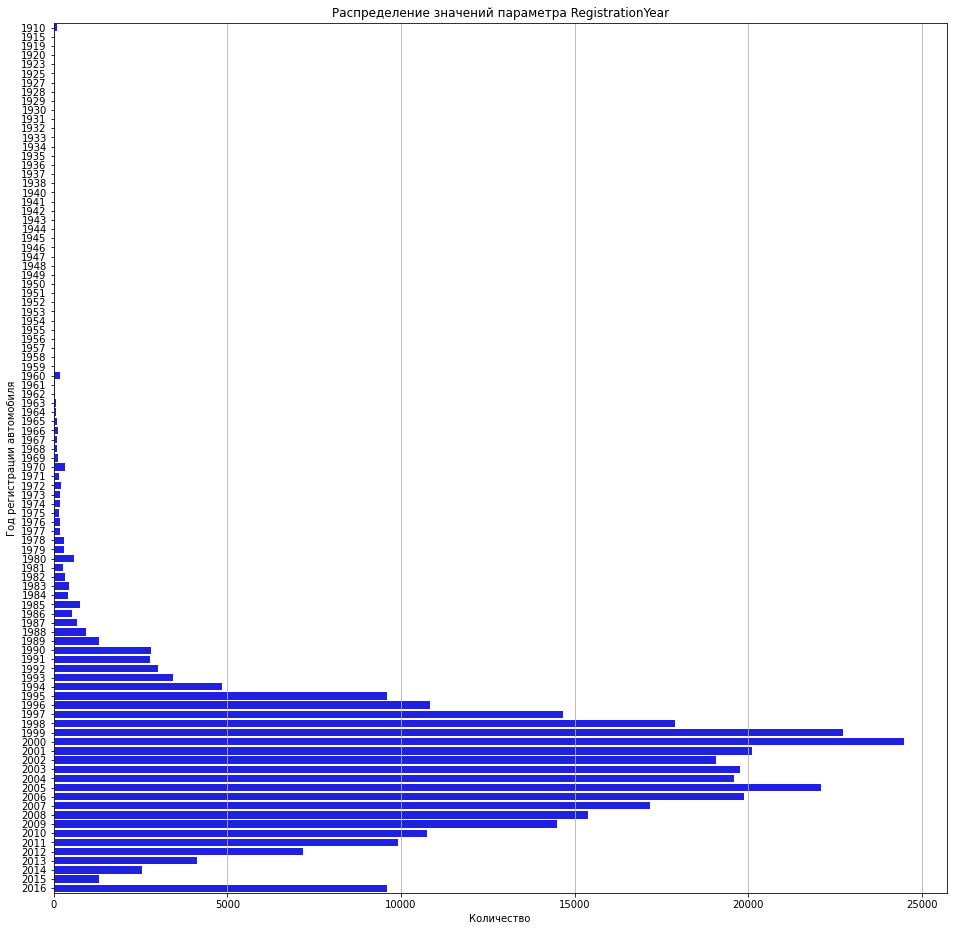

In [22]:
plt.figure(figsize = (16, 16))
sns.countplot(y = df_autos[(df_autos['RegistrationYear'] < 2017) & (df_autos['RegistrationYear'] > 1885)]['RegistrationYear'].sort_values(), color='blue')
plt.title('Распределение значений параметра RegistrationYear')
plt.xlabel('Количество')
plt.ylabel('Год регистрации автомобиля')
plt.grid(axis='x')
plt.show()

In [23]:
df_autos[(df_autos['RegistrationYear'] == 1910)].sample(5)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,PostalZone,BrandModel
176276,2016-03-19 20:57:47,0,other,1910,manual,0,NaN,100000,1,NaN,sonstige_autos,NaN,2016-03-19,8,sonstige_autos_nan
244840,2016-03-09 17:50:22,0,NaN,1910,NaN,0,other,5000,0,NaN,hyundai,NaN,2016-03-09,59,hyundai_other
303544,2016-03-18 08:48:28,0,NaN,1910,NaN,0,NaN,5000,0,NaN,sonstige_autos,NaN,2016-03-18,45,sonstige_autos_nan
213796,2016-03-06 11:38:23,1,suv,1910,NaN,0,NaN,5000,1,NaN,sonstige_autos,NaN,2016-03-06,94,sonstige_autos_nan
138140,2016-03-24 07:00:24,0,NaN,1910,NaN,0,combo,150000,0,NaN,opel,NaN,2016-03-24,8,opel_combo


Очень странные года регистрации. Есть явно некорректно указанные значения, такие как 1000, 9999, 5000 (видимо в форме заполнения данных это поле является обязательным, но никакой проверки не проходит), а так же года, не соответствующие годам выпусков автомобилей указанных брендов. Возможно, данный параметр вовсе не стоит учитывать при обучении моделей, т.к. он не связан с годом выпуска автомобиля и с годом, с которого началось владение автомобилем.

In [24]:
df_autos[(df_autos['RegistrationYear'] > 2016) | (df_autos['RegistrationYear'] < 1940)]['RegistrationYear'].count()

14752

In [25]:
def reg_year_correction(row):
    if row['RegistrationYear'] < 1940:
        return np.nan
    elif ((row['RegistrationYear'] > row['DateCreated'].year)
          or (row['RegistrationYear'] > row['DateCrawled'].year)):
        return np.nan
    elif ((row['RegistrationYear'] == row['DateCreated'].year)
          and (row['RegistrationMonth'] > row['DateCreated'].month)):
        return np.nan
    elif ((row['RegistrationYear'] == row['DateCrawled'].year)
          and (row['RegistrationMonth'] > row['DateCrawled'].month)):
        return np.nan
    else:
        return row['RegistrationYear']

In [26]:
df_autos['RegistrationYear'] = df_autos.apply(reg_year_correction, axis=1)

In [27]:
df_autos[df_autos['RegistrationYear'] > 2016]['RegistrationYear'].count()

0

In [28]:
df_autos[(df_autos['RegistrationYear'] == 2016) | (df_autos['RegistrationYear'].isna())].sample(5)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,PostalZone,BrandModel
50466,2016-03-17 22:55:42,12000,NaN,NaN,auto,177,a6,60000,5,NaN,audi,no,2016-03-17,56,audi_a6
251274,2016-04-03 19:45:49,4200,NaN,2016.0,auto,147,cr_reihe,150000,4,NaN,honda,NaN,2016-04-03,67,honda_cr_reihe
318135,2016-03-16 17:47:39,4999,NaN,NaN,manual,0,golf,150000,6,petrol,volkswagen,no,2016-03-16,45,volkswagen_golf
215086,2016-03-14 18:43:05,1400,NaN,NaN,manual,0,punto,150000,0,gasoline,fiat,NaN,2016-03-14,20,fiat_punto
242359,2016-03-26 14:40:54,3850,NaN,NaN,manual,102,a3,150000,9,petrol,audi,NaN,2016-03-26,26,audi_a3


Распределение признаков:

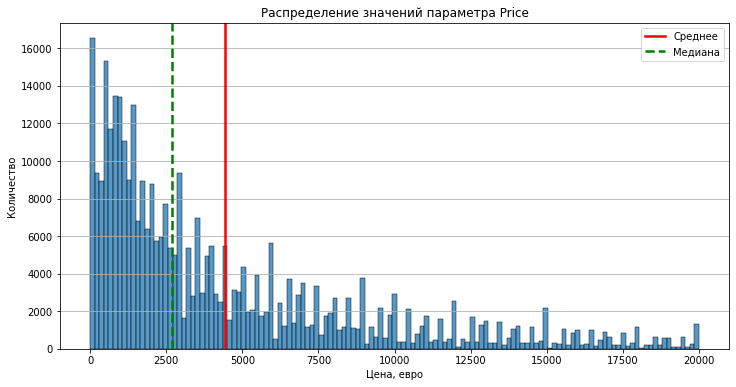

In [30]:
plt.figure(figsize = (12, 6))
fig = sns.histplot(data=df_autos, x=df_autos['Price'])
plt.axvline(df_autos['Price'].mean(), c='red', ls='-', lw=2.5, label='Среднее')
plt.axvline(df_autos['Price'].median(), c='green', ls='--', lw=2.5, label='Медиана')
plt.xlabel('Цена, евро')
plt.ylabel('Количество')
plt.title('Распределение значений параметра Price')
plt.legend()
plt.grid(axis='y')
plt.show()

In [31]:
df_autos[df_autos['Price'] < 10]['Price'].value_counts()

0    10771
1     1189
5       26
2       12
8        9
9        8
3        8
7        3
4        1
Name: Price, dtype: int64

In [32]:
df_autos[df_autos['Price'] == 0].sample(5)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,PostalZone,BrandModel
28178,2016-04-02 14:55:33,0,small,1996.0,manual,75,polo,150000,0,NaN,volkswagen,no,2016-04-02,16,volkswagen_polo
210817,2016-03-15 10:37:15,0,small,1995.0,auto,90,corsa,100000,5,petrol,opel,no,2016-03-15,57,opel_corsa
145586,2016-03-16 23:53:41,0,coupe,1994.0,manual,150,80,150000,12,petrol,audi,no,2016-03-16,45,audi_80
176455,2016-04-05 02:58:05,0,sedan,1999.0,manual,150,3er,150000,1,petrol,bmw,no,2016-04-05,85,bmw_3er
327851,2016-04-03 13:40:37,0,coupe,1997.0,manual,136,calibra,150000,6,petrol,opel,NaN,2016-04-03,24,opel_calibra


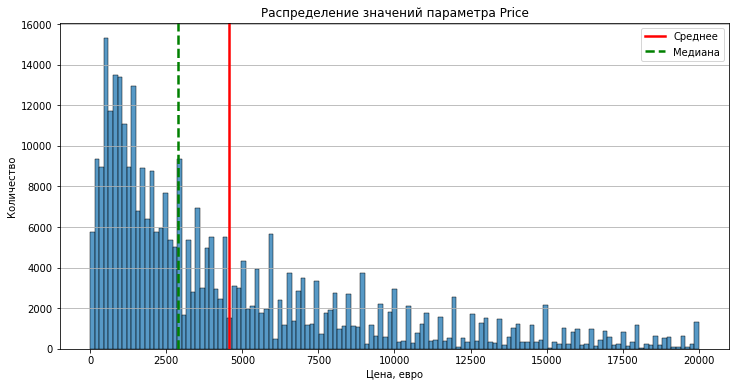

In [33]:
plt.figure(figsize = (12, 6))
fig = sns.histplot(data=df_autos, x=df_autos[df_autos['Price'] != 0]['Price'])
plt.axvline(df_autos[df_autos['Price'] != 0]['Price'].mean(), c='red', ls='-', lw=2.5, label='Среднее')
plt.axvline(df_autos[df_autos['Price'] != 0]['Price'].median(), c='green', ls='--', lw=2.5, label='Медиана')
plt.xlabel('Цена, евро')
plt.ylabel('Количество')
plt.title('Распределение значений параметра Price')
plt.legend()
plt.grid(axis='y')
plt.show()

Предположу, что Цена = 0 указана для автомобилей, цену которых не указывают в анкете, но обсуждают в дальнейшем в момент купле-продажи. Т.к. нулевые значения цены не помогут определить цену моделью, а наоборот могут немного сместить значения в меньшую сторону при обучении, то уберу эти данные из выборки для обучения.

In [34]:
df_autos = df_autos[df_autos['Price'] != 0]

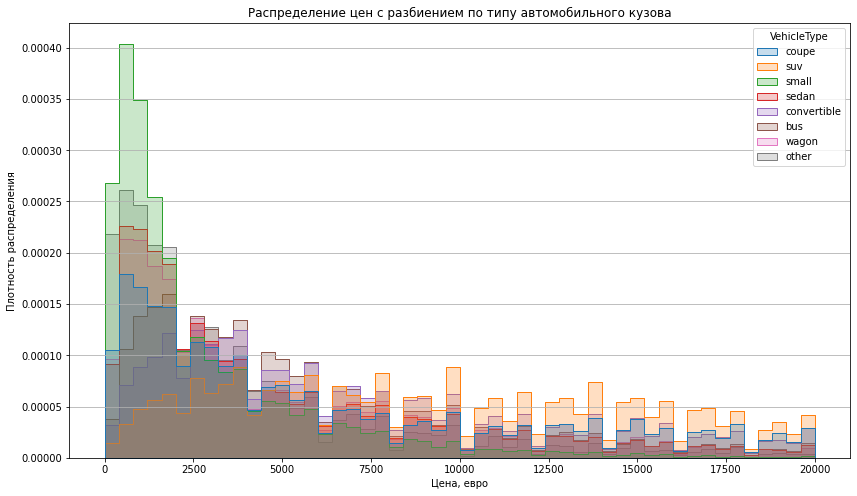

In [35]:
plt.figure(figsize = (14, 8))
plot_hist = sns.histplot(df_autos,
                         bins=50,
                         x='Price', 
                         hue='VehicleType', 
                         element='step', 
                         stat='density',
                         #fill=False,
                         #kde=True,
                         common_norm=False)
plt.title(f'Распределение цен с разбиением по типу автомобильного кузова')
plt.xlabel('Цена, евро')
plt.ylabel('Плотность распределения')
plt.grid(axis='y')
plt.show()

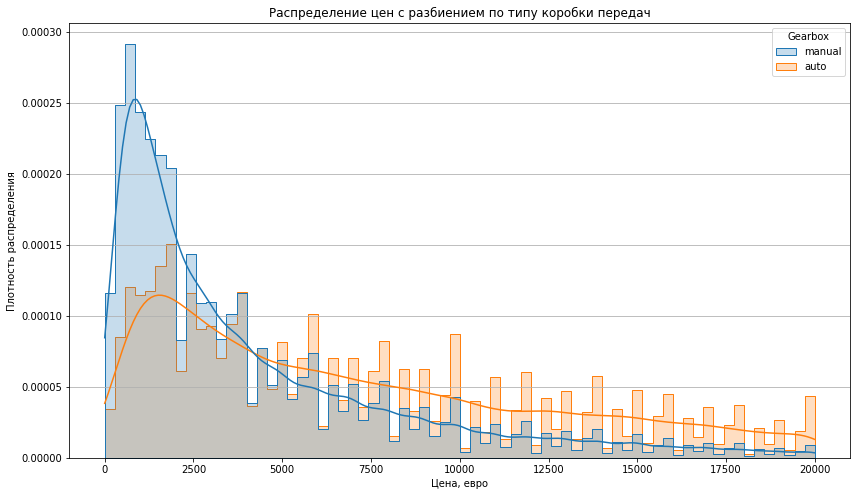

In [36]:
plt.figure(figsize = (14, 8))
plot_hist = sns.histplot(df_autos,
                         bins=70,
                         x='Price', 
                         hue='Gearbox', 
                         element='step', 
                         stat='density',
                         kde=True,
                         common_norm=False)
plt.title(f'Распределение цен с разбиением по типу коробки передач')
plt.xlabel('Цена, евро')
plt.ylabel('Плотность распределения')
plt.grid(axis='y')
plt.show()

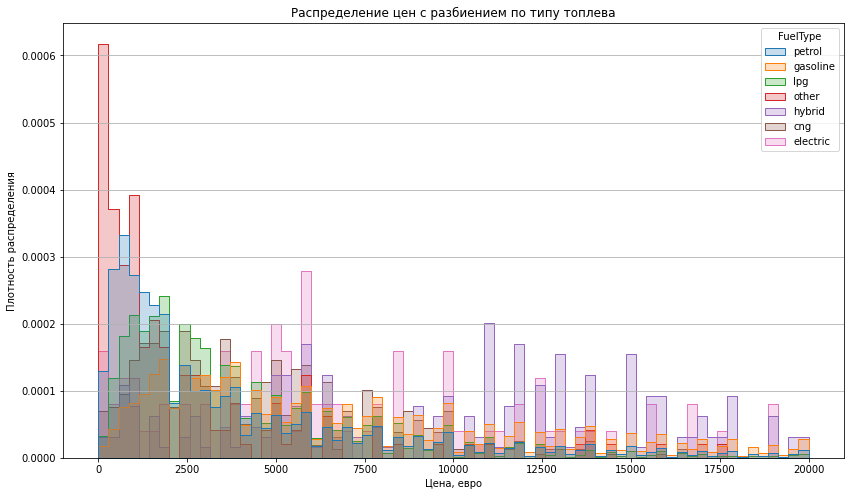

In [37]:
plt.figure(figsize = (14, 8))
plot_hist = sns.histplot(df_autos,
                         bins=70,
                         x='Price', 
                         hue='FuelType', 
                         element='step', 
                         stat='density',
                         #kde=True,
                         common_norm=False)
plt.title(f'Распределение цен с разбиением по типу топлева')
plt.xlabel('Цена, евро')
plt.ylabel('Плотность распределения')
plt.grid(axis='y')
plt.show()

In [38]:
df_autos[df_autos['Power'] == 20000]

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,PostalZone,BrandModel
219584,2016-03-09 15:43:53,4300,coupe,1999.0,auto,20000,clk,150000,1,petrol,mercedes_benz,no,2016-03-09,19,mercedes_benz_clk


Уменьшу запредельные значения мощностей, поделив указанное значение на 100

In [39]:
df_autos[df_autos['Power'] > 2000]

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,PostalZone,BrandModel
7661,2016-04-02 19:25:25,1499,small,1999.0,manual,7515,lupo,150000,4,petrol,volkswagen,NaN,2016-04-02,65,volkswagen_lupo
19092,2016-03-20 17:54:04,9750,wagon,2005.0,auto,2729,5er,150000,7,gasoline,bmw,no,2016-03-20,21,bmw_5er
25232,2016-03-28 19:57:39,10900,bus,2009.0,manual,10520,caddy,150000,6,gasoline,volkswagen,no,2016-03-28,36,volkswagen_caddy
33952,2016-03-09 11:37:03,3740,small,2006.0,manual,6920,aygo,90000,10,NaN,toyota,no,2016-03-09,94,toyota_aygo
36206,2016-04-01 01:56:06,5400,NaN,NaN,manual,2017,transporter,150000,8,gasoline,volkswagen,NaN,2016-03-31,10,volkswagen_transporter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346639,2016-03-25 12:55:36,1300,sedan,2000.0,manual,12512,carisma,150000,9,petrol,mitsubishi,NaN,2016-03-25,42,mitsubishi_carisma
346690,2016-03-24 11:50:41,7498,NaN,NaN,auto,2018,5er,150000,9,NaN,bmw,no,2016-03-24,59,bmw_5er
348137,2016-03-16 21:48:39,850,sedan,1993.0,auto,9012,golf,150000,0,petrol,volkswagen,NaN,2016-03-16,14,volkswagen_golf
348237,2016-04-04 12:38:11,3000,coupe,2007.0,manual,2007,corsa,150000,3,gasoline,opel,yes,2016-04-04,72,opel_corsa


In [40]:
df_autos['Power'] = df_autos['Power'].apply(lambda x: x / 100 if x > 2_020 else x)

In [41]:
df_autos[df_autos['Power'] > 1900].sample(5)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,PostalZone,BrandModel
92455,2016-03-15 22:53:58,6900,sedan,2007.0,manual,1968.0,passat,150000,5,gasoline,volkswagen,no,2016-03-15,20,volkswagen_passat
313582,2016-04-02 15:55:11,1250,wagon,2003.0,auto,1998.0,passat,5000,12,gasoline,volkswagen,no,2016-04-02,33,volkswagen_passat
28942,2016-03-21 21:58:07,300,wagon,1996.0,manual,1999.0,golf,10000,0,petrol,volkswagen,NaN,2016-03-21,32,volkswagen_golf
288511,2016-03-15 12:36:57,599,NaN,NaN,NaN,2016.0,corsa,150000,5,NaN,opel,NaN,2016-03-15,47,opel_corsa
64823,2016-03-21 19:43:36,10000,wagon,2008.0,manual,2005.0,sprinter,150000,1,gasoline,mercedes_benz,no,2016-03-21,40,mercedes_benz_sprinter


In [42]:
df_autos[df_autos['Power'] > 1900]['Power'].count()

31

Для данного перечня автомобилей скорее всего просто было ошибочно заполнено поле мощности значением года выпуска автомобиля. Чтобы не выставлять значения, сверяясь с данными по каждому автомобилю, что нельзя будет реализовать автоматически при дальнейшем применении модели на прод данных, лучше использовать медиану значений мощности с разбивкой по бренду, модели и типу коробки передач.

In [43]:
df_autos[df_autos['Power'] < 10]['Power'].value_counts()

0.0    36358
5.0      101
4.0       30
1.0       27
6.0       11
7.0       10
2.0        9
3.0        9
8.0        7
9.0        5
Name: Power, dtype: int64

In [44]:
df_autos['Power'].nunique()

691

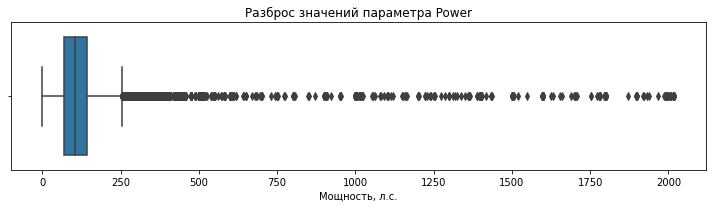

In [45]:
plt.figure(figsize = (10, 3))
sns.boxplot(x=df_autos['Power'])
plt.title('Разброс значений параметра Power')
plt.xlabel('Мощность, л.с.')
plt.tight_layout()
plt.show()

In [46]:
pivot_power_medians = (df_autos[((df_autos['Power'] >= 50)
                                & (df_autos['Power'] <= 400))]
                       .groupby(['Brand', 'Model', 'Gearbox'])['Power']
                       .median()
                       .reset_index())
common_power_median = df_autos[((df_autos['Power'] >= 50) & (df_autos['Power'] <= 400))]['Power'].median()

In [47]:
def fix_value_power(row):
    if row['Power'] < 50 or row['Power'] > 400:
        if row['Model'] is np.nan or row['Gearbox'] is np.nan:
            power = common_power_median
        else:
            try:
                power = pivot_power_medians[((pivot_power_medians['Brand'] == row['Brand'])
                                             & (pivot_power_medians['Model'] == row['Model'])
                                             & (pivot_power_medians['Gearbox'] == row['Gearbox']))]['Power'].values[0]
            except:
                power = common_power_median
    else:
        power = row['Power']
    return power

In [48]:
df_autos['Power'] = df_autos.apply(fix_value_power, axis=1)

In [49]:
df_autos.sample(5)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,PostalZone,BrandModel
296999,2016-03-14 14:00:41,3200,wagon,2006.0,NaN,113.0,a3,150000,7,gasoline,audi,no,2016-03-14,50,audi_a3
142391,2016-04-01 14:49:58,19900,sedan,2010.0,auto,184.0,e_klasse,50000,3,petrol,mercedes_benz,no,2016-04-01,12,mercedes_benz_e_klasse
145081,2016-03-18 01:57:25,5900,wagon,2008.0,manual,90.0,NaN,150000,3,gasoline,mercedes_benz,NaN,2016-03-18,23,mercedes_benz_nan
206304,2016-04-04 23:00:10,340,NaN,2016.0,manual,113.0,NaN,150000,4,NaN,opel,no,2016-04-04,71,opel_nan
52174,2016-03-10 00:48:58,4050,sedan,2005.0,manual,105.0,golf,150000,9,gasoline,volkswagen,NaN,2016-03-09,38,volkswagen_golf


In [50]:
df_autos['Power'].nunique()

414

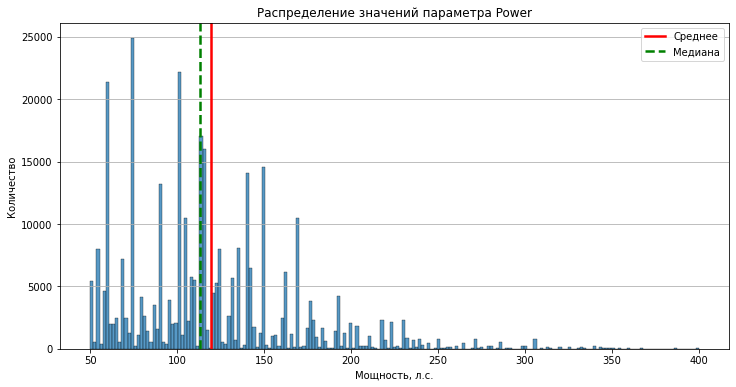

In [51]:
plt.figure(figsize = (12, 6))
sns.histplot(data=df_autos, x=df_autos['Power'])
#sns.histplot(data=df_autos, x=df_autos['Power'])
plt.axvline(df_autos['Power'].mean(), c='red', ls='-', lw=2.5, label='Среднее')
plt.axvline(df_autos['Power'].median(), c='green', ls='--', lw=2.5, label='Медиана')
plt.xlabel('Мощность, л.с.')
plt.ylabel('Количество')
plt.title('Распределение значений параметра Power')
plt.legend()
plt.grid(axis='y')
plt.show()

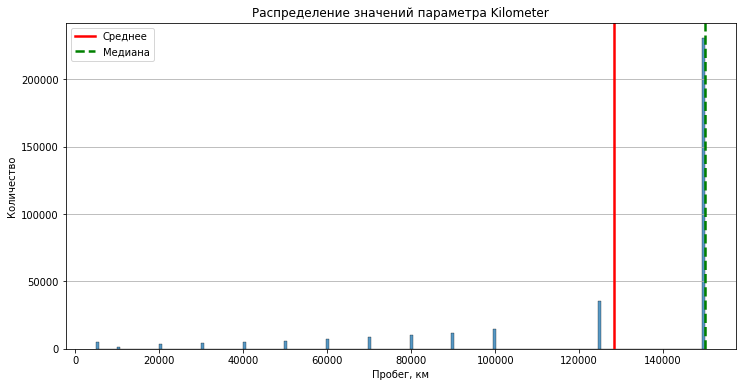

In [52]:
plt.figure(figsize = (12, 6))
sns.histplot(data=df_autos, x=df_autos['Kilometer'])
plt.axvline(df_autos['Kilometer'].mean(), c='red', ls='-', lw=2.5, label='Среднее')
plt.axvline(df_autos['Kilometer'].median(), c='green', ls='--', lw=2.5, label='Медиана')
plt.xlabel('Пробег, км')
plt.ylabel('Количество')
plt.title('Распределение значений параметра Kilometer')
plt.legend()
plt.grid(axis='y')
plt.show()

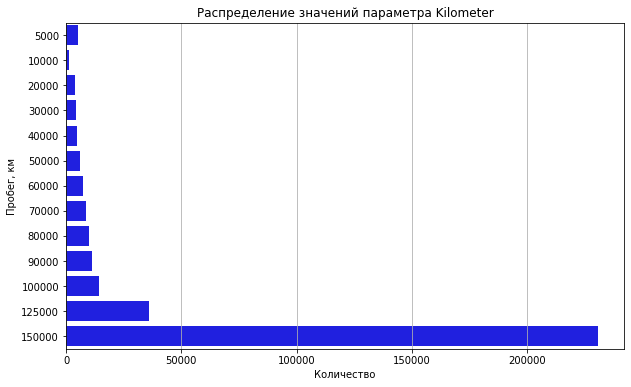

In [53]:
plt.figure(figsize = (10, 6))
sns.countplot(y = df_autos['Kilometer'].sort_values(), color='blue')
plt.title('Распределение значений параметра Kilometer')
plt.xlabel('Количество')
plt.ylabel('Пробег, км')
plt.grid(axis='x')
plt.show()

In [54]:
df_autos['Kilometer'].value_counts()

150000    230480
125000     35756
100000     14438
90000      11388
80000       9898
70000       8489
60000       7368
50000       6152
5000        5372
40000       4854
30000       4332
20000       3836
10000       1146
Name: Kilometer, dtype: int64

Значения параметра Kilometer дисретны, всего 13 возможных вариантов значений.

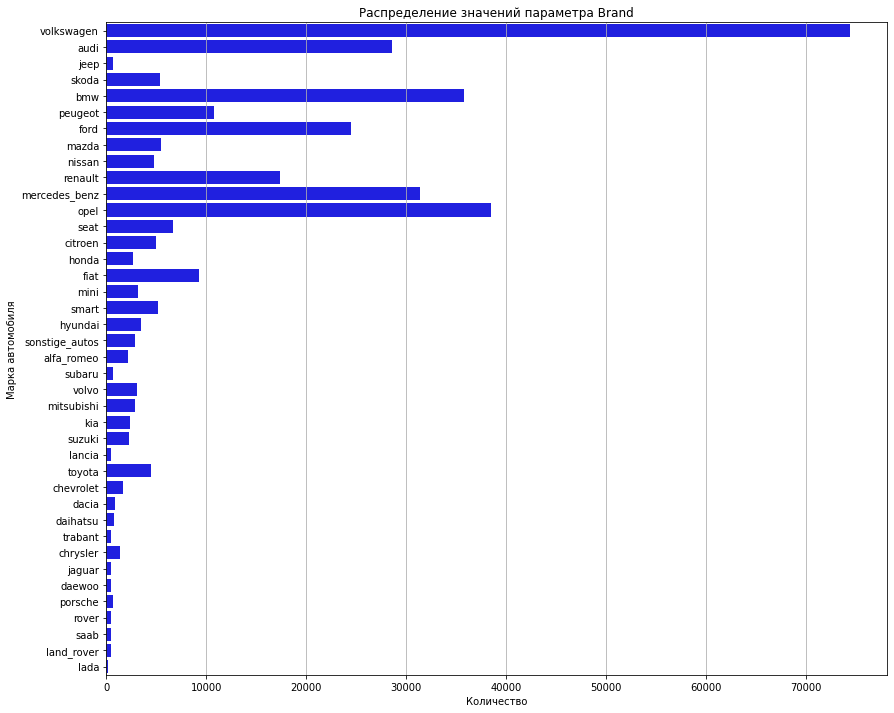

In [55]:
plt.figure(figsize = (14, 12))
sns.countplot(y = df_autos['Brand'], color='blue')
plt.title('Распределение значений параметра Brand')
plt.xlabel('Количество')
plt.ylabel('Марка автомобиля')
plt.grid(axis='x')
plt.show()

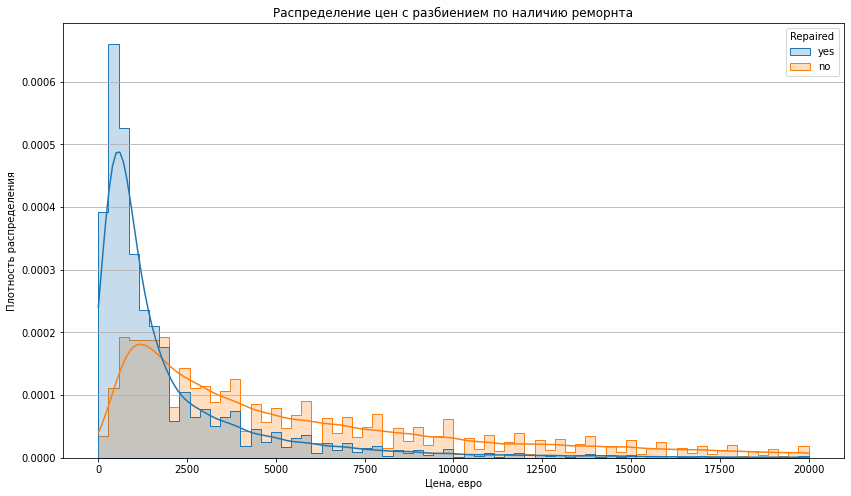

In [56]:
plt.figure(figsize = (14, 8))
plot_hist = sns.histplot(df_autos,
                         bins=70,
                         x='Price', 
                         hue='Repaired', 
                         element='step', 
                         stat='density',
                         kde=True,
                         common_norm=False)
plt.title(f'Распределение цен с разбиением по наличию реморнта')
plt.xlabel('Цена, евро')
plt.ylabel('Плотность распределения')
plt.grid(axis='y')
plt.show()

In [57]:
df_autos = df_autos.drop(['DateCrawled', 
                          'RegistrationMonth', 
                          'DateCreated'], axis=1)
df_autos.sample(3)

,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,FuelType,Brand,Repaired,PostalZone,BrandModel
203175,1700,bus,1999.0,manual,60.0,fiesta,125000,petrol,ford,no,42,ford_fiesta
107256,1600,bus,2001.0,manual,85.0,zafira,150000,gasoline,opel,NaN,30,opel_zafira
100324,15700,bus,2011.0,manual,105.0,touran,60000,gasoline,volkswagen,no,38,volkswagen_touran


### Просмотр корреляции

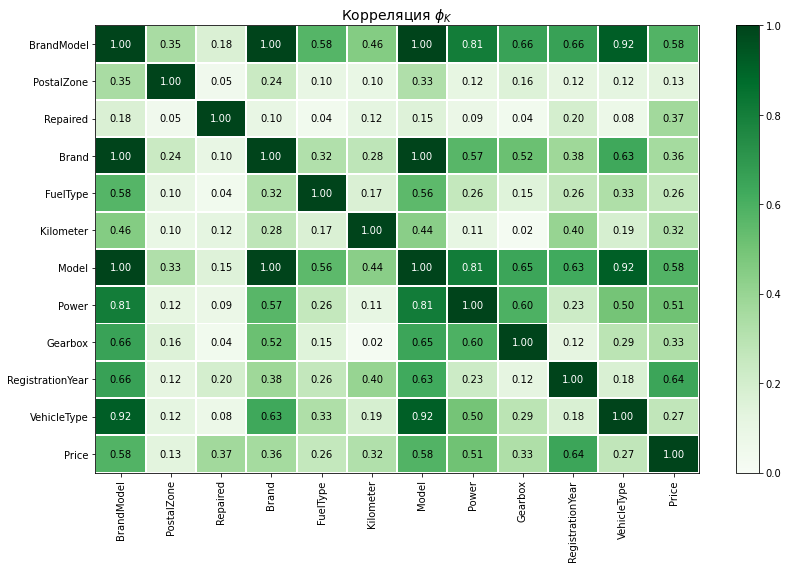

In [58]:
interval_cols = ['Price','RegistrationYear', 'Power']
phik_overview = phik_matrix(df_autos, interval_cols=interval_cols)
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'Корреляция $\phi_K$',
    fontsize_factor=1.0,
    figsize=(12, 8)
)

In [59]:
df_autos[df_autos['Brand'].isna()]['Price'].count()

0

In [60]:
df_autos[df_autos['Model'].isna()]['Price'].count()

17521

In [61]:
df_autos = df_autos.drop(['Brand', 'Model'], axis=1)

Между маркой и моделью сильная корреляция, что вполне логично. Можно было бы оставить только Model, но у параметра есть пропуски. Поэтому вместо отдельных параметров буду использовать скомбинированный BrandModel.

Полной зависимости параметров с целевым признаком нет, значит нет утечки данных в определении цены.

### Подготовка выборок

In [62]:
df_autos.sample(5)

,Price,VehicleType,RegistrationYear,Gearbox,Power,Kilometer,FuelType,Repaired,PostalZone,BrandModel
175073,2499,bus,1999.0,manual,116.0,150000,lpg,no,48,opel_zafira
43904,1850,sedan,1997.0,manual,170.0,150000,petrol,no,48,bmw_5er
2353,2550,sedan,1995.0,manual,150.0,150000,petrol,no,85,audi_a4
70778,6950,small,2009.0,manual,86.0,100000,petrol,no,49,seat_ibiza
163613,400,NaN,2002.0,auto,150.0,150000,NaN,no,66,alfa_romeo_147


In [63]:
df_autos['Kilometer'].sort_values().unique()

array([  5000,  10000,  20000,  30000,  40000,  50000,  60000,  70000,
        80000,  90000, 100000, 125000, 150000])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    df_autos.drop(['Price'], axis=1),
    df_autos['Price'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE
)

print('Размеры тренировочной и тестовой выборок:')
X_train.shape, y_train.shape, X_test.shape, y_test.shape

Размеры тренировочной и тестовой выборок:


((257631, 9), (257631,), (85878, 9), (85878,))

In [65]:
ohe_columns = ['Gearbox', 'Repaired']
te_columns = ['VehicleType', 'BrandModel', 'FuelType']
#ord_columns = ['Kilometer']
num_columns = ['Kilometer', 'RegistrationYear', 'Power']

ohe_pipe = Pipeline(
    [
        ('imputer', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='unknown')),
        ('ohe', OneHotEncoder(handle_unknown='infrequent_if_exist', drop='first', sparse_output=False))
    ]
)

te_pipe = Pipeline(
    [
        ('imputer', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='unknown')),
        ('te', TargetEncoder(categories='auto', target_type='continuous', random_state=RANDOM_STATE))
    ]
)

num_pipe = Pipeline(
    [
        ('imputer', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('scaler', StandardScaler())
    ]
)

In [66]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('te', te_pipe, te_columns),
#        ('ord', ord_pipe, ord_columns),
        ('num', num_pipe, num_columns)
    ],
    remainder='passthrough'
)
data_preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('ohe',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='unknown',
                                                                strategy='constant')),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='infrequent_if_exist',
                                                                sparse_output=False))]),
                                 ['Gearbox', 'Repaired']),
                                ('te',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='unknown',
                                                                strategy='constant')),
                                                 ('te',
                                                  TargetEncoder(random_state=133,
                                                                target_type='continuous'))]),
                                 ['VehicleType', 'BrandModel', 'FuelType']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('scaler', StandardScaler())]),
                                 ['Kilometer', 'RegistrationYear', 'Power'])])

В рамках подготовки данных были выполнены следующие действия:

Были убраны из входных данных колонки:
- "дата скачивания анкеты из базы", "дата создания анкеты", "количество фотографий автомобиля" - т.к. относятся к анкете и не влияют на цену автомобиля
- "месяц регистрации автомобиля" - т.к. для определения цены автомобиля основным фактором является год его выпуска
- "почтовый индекс владельца анкеты (пользователя)", "дата последней активности пользователя" - т.к. относятся к информации о пользователе и не влияют на цену автомобиля

Вместо полного почтового индекса был добавлен параметр почтовой зоны.

Были удалены дубликаты в количестве 89.

Была выполнена проверка на неявные дубликаты. Неявных дубликатов не было обнаружено. Все строковые значения указаны в нижнем регистре, преобразование не понадобилось.

Был проведён анализ значений параметров. Были убраны аномалии в значениях параметра Power. Было выявлено, что значения параметра Kilometer имеют дискретный тип.

Была выполнена проверка на наличие корреляции между параметрами. Т.к. Brand и Model имеют полную корреляцию, был оставлен скомбинированный параметр BrandModel.

Было выполнено разбиение данных на тренировочную и тестовую выборки.

Был подготовлен пайплан с шагами кодирования данных.

## Обучение моделей

Проверка метрики RMSE на Dummy модели перед обучением целевых моделей:

In [68]:
X, X_v, y, y_v = train_test_split(
    X_train,
    y_train,
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE)

print('Размеры тренировочной и валидационной выборок:')
print(X.shape, X_v.shape)
print(y.shape, y_v.shape)

pipe_final_dummy = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DummyRegressor())
    ]
)
pipe_final_dummy.fit(X, y)
y_pred_dummy = pipe_final_dummy.predict(X_v)
print(f'Метрика RMSE на валидационной выборке для Dummy модели: {round(RMSE(y_v, y_pred_dummy), 3)}')

Размеры тренировочной и валидационной выборок:
(193223, 9) (64408, 9)
(193223,) (64408,)
Метрика RMSE на валидационной выборке для Dummy модели: 4524.233


### Подбор параметров для моделей

In [69]:
def best_lgbm_params(trial):    
    learning_rate = trial.suggest_float("learning_rate", 1e-2, 1, log=True)
    n_estimators = trial.suggest_int("n_estimators", 10, 300)
    
    pipe_final = Pipeline(
        [
            ('preprocessor', data_preprocessor),
            ('models', LGBMRegressor(
                learning_rate=learning_rate,
                n_estimators=n_estimators,
                random_state=RANDOM_STATE))
        ]
    )

    score = cross_val_score(pipe_final, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error').mean() * -1
    print(score)
        
    return score

In [70]:
study_lgbm = optuna.create_study(direction="minimize")
start = time.time()
study_lgbm.optimize(best_lgbm_params, n_trials=5, n_jobs=-1)
print(f'Общее время подбора параметров модели: {(time.time() - start):.3f} секунд')

[I 2025-09-18 10:12:54,120] A new study created in memory with name: no-name-2604a3e3-3cdf-441a-b41a-f8654b04250b
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was

1779.5028913415497


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
[I 2025-09-18 10:14:07,914] Trial 4 finished with value: 1817.0975890570505 and parameters: {'learning_rate': 0.7270121218650097, 'n_estimators': 64}. Best is trial 2 with value: 1779.5028913415497.


1817.0975890570505


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
[I 2025-09-18 10:14:26,525] Trial 3 finished with value: 1885.823771763451 and parameters: {'learning_rate': 0.042396607899575015, 'n_estimators': 99}. Best is trial 2 with value: 1779.5028913415497.


1885.823771763451


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
[I 2025-09-18 10:14:42,418] Trial 1 finished with value: 2049.625510367945 and parameters: {'learning_rate': 0.018601405269947465, 'n_estimators': 127}. Best is trial 2 with value: 1779.5028913415497.


2049.625510367945


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
[I 2025-09-18 10:20:45,015] Trial 0 finished with value: 1862.0180771427688 and parameters: {'learning_rate': 0.026939662932503404, 'n_estimators': 185}. Best is trial 2 with value: 1779.5028913415497.


1862.0180771427688
Общее время подбора параметров модели: 470.896 секунд


In [71]:
print(f'Значение RMSE кросс-валидационной выборки для модели LGBMRegressor:\n {study_lgbm.best_value}')
print(f'Параметры, подобранные для модели LGBMRegressor:\n {study_lgbm.best_params}')

Значение RMSE кросс-валидационной выборки для модели LGBMRegressor:
 1779.5028913415497
Параметры, подобранные для модели LGBMRegressor:
 {'learning_rate': 0.3529493758060571, 'n_estimators': 62}


In [72]:
pipe_final_lgbm = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', LGBMRegressor(**study_lgbm.best_params,
                                 random_state=RANDOM_STATE))
    ]
)

In [73]:
def best_rf_params(trial):
    n_estimators = trial.suggest_int("n_estimators", 1, 50)
    max_depth = trial.suggest_int("max_depth", 5, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 8)
    
    pipe_final = Pipeline(
        [
            ('preprocessor', data_preprocessor),
            ('models', RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                #warm_start=True,
                random_state=RANDOM_STATE))
        ]
    )

    score = cross_val_score(pipe_final, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error').mean() * -1
    print(score)
        
    return score

In [74]:
study_rf = optuna.create_study(direction="minimize")
start = time.time()
study_rf.optimize(best_rf_params, n_trials=5, n_jobs=-1)
print(f'Общее время подбора модели: {(time.time() - start):.3f} секунд')

[I 2025-09-18 10:20:45,280] A new study created in memory with name: no-name-d92b8121-0b61-48d3-aa74-268b994a7b93
[I 2025-09-18 10:22:47,816] Trial 0 finished with value: 2392.6865166085227 and parameters: {'n_estimators': 24, 'max_depth': 5, 'min_samples_split': 2}. Best is trial 0 with value: 2392.6865166085227.


2392.6865166085227


[I 2025-09-18 10:23:12,519] Trial 2 finished with value: 2391.8650959679157 and parameters: {'n_estimators': 33, 'max_depth': 5, 'min_samples_split': 3}. Best is trial 2 with value: 2391.8650959679157.


2391.8650959679157


[I 2025-09-18 10:24:08,010] Trial 3 finished with value: 1874.9791966450575 and parameters: {'n_estimators': 30, 'max_depth': 11, 'min_samples_split': 4}. Best is trial 3 with value: 1874.9791966450575.


1874.9791966450575


[I 2025-09-18 10:25:33,550] Trial 1 finished with value: 1728.0045398675522 and parameters: {'n_estimators': 40, 'max_depth': 19, 'min_samples_split': 5}. Best is trial 1 with value: 1728.0045398675522.


1728.0045398675522


[I 2025-09-18 10:25:48,034] Trial 4 finished with value: 1722.8429083834453 and parameters: {'n_estimators': 44, 'max_depth': 26, 'min_samples_split': 8}. Best is trial 4 with value: 1722.8429083834453.


1722.8429083834453
Общее время подбора модели: 302.754 секунд


In [75]:
print(f'Значение RMSE кросс-валидационной выборки для модели RandomForestRegressor:\n {study_rf.best_value}')
print(f'Параметры, подобранные для модели RandomForestRegressor:\n {study_rf.best_params}')

Значение RMSE кросс-валидационной выборки для модели RandomForestRegressor:
 1722.8429083834453
Параметры, подобранные для модели RandomForestRegressor:
 {'n_estimators': 44, 'max_depth': 26, 'min_samples_split': 8}


In [76]:
pipe_final_rf = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', RandomForestRegressor(**study_rf.best_params,
                                         random_state=RANDOM_STATE))
    ]
)

In [77]:
def best_svr_params(trial):
    kernel = trial.suggest_categorical("kernel", ['linear', 'poly', 'rbf'])
    max_iter = trial.suggest_int("max_iter", 2, 20)
    
    pipe_final = Pipeline(
        [
            ('preprocessor', data_preprocessor),
            ('models', SVR(kernel=kernel, max_iter=max_iter))
        ]
    )

    score = cross_val_score(pipe_final, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error').mean() * -1
    print(score)
        
    return score

In [78]:
study_svr = optuna.create_study(direction="minimize")
start = time.time()
study_svr.optimize(best_svr_params, n_trials=3, n_jobs=1)
print(f'Общее время подбора модели: {(time.time() - start):.3f} секунд')

[I 2025-09-18 10:25:48,094] A new study created in memory with name: no-name-c765217a-ffde-4a7b-9aac-ff8530ed2996
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=8).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=8).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=8).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
[I 2025-09-18 10:25:51,073] Trial 0 finished with value: 7075.730990340525 and parameters: {'kernel': 'poly', 'max_iter': 8}. Best is trial 0 with value: 7075.730990340525.


7075.730990340525


/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=9).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=9).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=9).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
[I 2025-09-18 10:25:54,064] Trial 1 finished with value: 7075.703190426369 and parameters: {'kernel': 'poly', 'max_iter': 9}. Best is trial 1 with value: 7075.703190426369.


7075.703190426369


/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
[I 2025-09-18 10:25:56,832] Trial 2 finished with value: 134711.40604736833 and parameters: {'kernel': 'linear', 'max_iter': 5}. Best is trial 1 with value: 7075.703190426369.


134711.40604736833
Общее время подбора модели: 8.738 секунд


In [79]:
print(f'Значение RMSE кросс-валидационной выборки для модели SVR:\n {study_svr.best_value}')
print(f'Параметры, подобранные для модели SVR:\n {study_svr.best_params}')

Значение RMSE кросс-валидационной выборки для модели SVR:
 7075.703190426369
Параметры, подобранные для модели SVR:
 {'kernel': 'poly', 'max_iter': 9}


In [80]:
pipe_final_svr = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', SVR(**study_svr.best_params))
    ]
)

In [81]:
pipe_final_lr = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', LinearRegression())
    ]
)

## Анализ моделей

In [82]:
def train_predict_time(name, pipe_final):
    
    start = time.time()
    pipe_final.fit(X, y)
    train_time = round(time.time() - start, 3)
    
    start = time.time()
    y_pred = pipe_final.predict(X_v)
    predict_time = round(time.time() - start, 3)
    
    rmse = round(RMSE(y_v, y_pred), 3)

    return {'model': name, 'train_time': train_time, 'predict_time': predict_time, 'RMSE': rmse}

In [83]:
models = {
    'DummyRegressor': pipe_final_dummy,
    'LGBMRegressor': pipe_final_lgbm,
    'RandomForestRegressor': pipe_final_rf,
    'SVR': pipe_final_svr,
    'LinearRegression': pipe_final_lr
}

common_df_metrics = pd.DataFrame(data=[], columns=['model', 'train_time', 'predict_time', 'RMSE'])

for name, model in models.items():
    common_df_metrics = common_df_metrics.append((train_predict_time(name, model)),
                                                 ignore_index=True)

common_df_metrics

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=9).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,model,train_time,predict_time,RMSE
0,DummyRegressor,0.581,0.157,4524.233
1,LGBMRegressor,197.190,0.494,1770.390
2,RandomForestRegressor,35.231,1.011,1693.084
3,SVR,0.760,0.169,7065.400
4,LinearRegression,0.684,0.239,2772.783


Из выбранных моделей RMSE ниже необходимого 2500 показали модели LGBMRegressor и RandomForestRegressor. У LGBMRegressor значение RMSE чуть лучше, чем у RandomForestRegressor, но зато RandomForestRegressor быстрее обучается и быстрее выполняет предсказание. Для финальной проверки на тестовой выборке будет выбрана RandomForestRegressor.

In [84]:
print(f'Финальная проверка на моделе RandomForestRegressor с подобранными гиперпараметрами\n {study_rf.best_params}')
start = time.time()
y_test_pred = pipe_final_rf.predict(X_test)
print(f'Время выполнения предсказания на тестовой выборке модели: {(time.time() - start):.3f} секунд')
print(f'Метрика RMSE на тестовой выборке: {round(RMSE(y_test, y_test_pred), 3)}')

Финальная проверка на моделе RandomForestRegressor с подобранными гиперпараметрами
 {'n_estimators': 44, 'max_depth': 26, 'min_samples_split': 8}
Время выполнения предсказания на тестовой выборке модели: 1.434 секунд
Метрика RMSE на тестовой выборке: 1715.121


Значение RMSE на тестовой выборке не сильно отличается от значения на валидационной, значит модель не ухудшла качество при смене выборки.

В ходе работы для обучения были выбраны 4 модели LGBMRegressor, RandomForestRegressor, SVR, LinearRegression. Для моделей были подобраны гиперпараметры. Наилучшие результаты показали модели LGBMRegressor и RandomForestRegressor (значения RMSE 1770 и 1693 соответственно), и т.к. RandomForestRegressor обучается и предсказывает быстрее, имеет допутимый уровень RMSE, то она была выбрана в качестве финальной.
Модель SVR показала качество хуже, чем Dummy модель, т.е. её предсказания хуже случайно выставленных значений.
Модель LinearRegression превысила допустимый порог значения RMSE, средняя ошибка у неё составляет 2773.

## Общий вывод

В рамках проекта было выполнено: 

Загрузка и подготовка данных:
- Были убраны из входных данных колонки, не влияющие на целевой признак ("дата скачивания анкеты из базы", "дата создания анкеты", "количество фотографий автомобиля", "месяц регистрации автомобиля", "почтовый индекс владельца анкеты (пользователя)", "дата последней активности пользователя")
- Вместо полного почтового индекса был добавлен параметр почтовой зоны.
- Были удалены дубликаты в количестве 89.
- Была выполнена проверка на неявные дубликаты. Неявных дубликатов не было обнаружено. Все строковые значения указаны в нижнем регистре, преобразование не понадобилось.
- Был проведён анализ значений параметров. Были убраны аномалии в значениях параметра Power. Было выявлено, что значения параметра Kilometer имеют дискретный тип.
- Была выполнена проверка на наличие корреляции между параметрами. Т.к. Brand и Model имеют полную корреляцию, был оставлен скомбинированный параметр BrandModel.
- Было выполнено разбиение данных на тренировочную и тестовую выборки.
- Было выполнено кодирование данных в соответствии с их типами.

Обучение и анализ моделей:
- Были подобраны параметры для 4 моделей разных типов: LGBMRegressor, RandomForestRegressor, SVR, LinearRegression
- Были выполнены обучение и оценка выбранных моделей 
- Определена лучшая модель с учётом требований заказчика по 3 параметрам: качество предсказания, скорость предсказания, время обучения

Наилучшие результаты показали модели LGBMRegressor и RandomForestRegressor (значения RMSE 1770 и 1693 соответственно), и т.к. RandomForestRegressor обучается и предсказывает быстрее, имеет допутимый уровень RMSE, то она была выбрана в качестве финальной. На выбранной модели было выполнено предсказание для тестовой выборки.